<a href="https://colab.research.google.com/github/Joana123-collab/Data-Science-I/blob/main/ProyectoParteIII%2BJoanaMuchut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de empresas en quiebra 🏦

Para este análisis se utilizó un dataset público obtenido de Kaggle, que contiene información financiera detallada de empresas, incluyendo 95 indicadores financieros. Estos indicadores abarcan métricas de rentabilidad (como el ROA), liquidez (como el ratio de liquidez corriente), apalancamiento y otros parámetros contables relevantes.

➡ El objetivo es analizar si estas variables permiten anticipar la probabilidad de quiebra de una empresa.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


# Enlace público de Github
url= "https://github.com/Joana123-collab/Data-Science-I/raw/refs/heads/main/DISTRESSDATASET_DATASCIENCE.csv"
df = pd.read_csv(url, on_bad_lines= 'skip', sep=',', encoding='latin-1')

# Mostramos las primeras filas
print(df.head())

   ¿En quiebra?  \
0             1   
1             1   
2             1   
3             1   
4             1   

    ROA(C): Retorno sobre activos (antes de intereses y depreciación)  \
0                                           0.370594                    
1                                           0.464291                    
2                                           0.426071                    
3                                           0.399844                    
4                                           0.465022                    

    ROA(A): Retorno sobre activos (antes de impuestos)  \
0                                           0.424389     
1                                           0.538214     
2                                           0.499019     
3                                           0.451265     
4                                           0.538432     

    ROA(B): Retorno sobre activos (después de impuestos)  \
0                                    

# ✍**Problema:**

Predecir si una empresa podría entrar en quiebra basándose en 95 indicadores financieros.

# 🎯**Objetivo:**

Construir un modelo de clasificación que identifique empresas en riesgo con un Recall > 85% (priorizando detectar la mayor cantidad de quiebras posibles).

# 🤔**Hipótesis:**

**H1)** Las variables relacionadas con **deuda ** (X36 - Deuda Total/Patrimonio Neto), **liquidez** (X33 - Ratio de Liquidez Corriente) y **rentabilidad** (X1 - ROA) serán las más relevantes para predecir quiebras.

**H2)** Es posible predecir la quiebra de las empresas con una precisión superior al 75% y un AUC superior a 0.5 utilizando las características proporcionadas y un modelo de Random Forest.

# Análisis exploratorio de datos


🔍 EDA INICIAL:
Shape: (6819, 97)

Tipos de datos:
 ¿En quiebra?                                                            int64
 ROA(C): Retorno sobre activos (antes de intereses y depreciación)    float64
 ROA(A): Retorno sobre activos (antes de impuestos)                   float64
 ROA(B): Retorno sobre activos (después de impuestos)                 float64
 Margen bruto operativo                                               float64
                                                                       ...   
 Pasivos/Patrimonio                                                   float64
 Grado de apalancamiento financiero (DFL)                             float64
 Cobertura de intereses (EBIT/Gastos financieros)                       int64
 Indicador de beneficio neto (Positivo/Negativo)                      float64
 Patrimonio/Pasivos                                                   float64
Length: 97, dtype: object

Primeras filas:
    ¿En quiebra?  \
0             1   
1       

<ipython-input-44-d9c58ccc128f>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='¿En quiebra?', data=df, palette=paleta_lila)


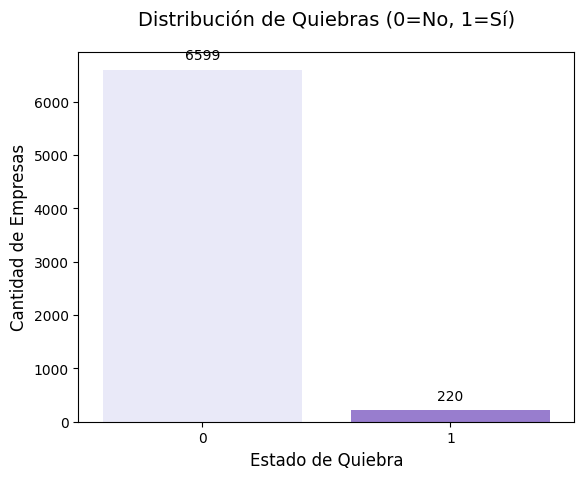

In [44]:
#Analisis inicial
print("\n🔍 EDA INICIAL:")
print("Shape:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nPrimeras filas:\n", df.head())

#Analisis del target
print("\n📊 DISTRIBUCIÓN DEL TARGET (¿En quiebra?):")
print(df['¿En quiebra?'].value_counts(normalize=True))

# Gráfico de distribución del target
paleta_lila = {"0": "lavender", "1": "mediumpurple"}
ax = sns.countplot(x='¿En quiebra?', data=df, palette=paleta_lila)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",  # Texto: valor de la barra (convertido a entero)
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Posición (x, y)
        ha='center',  # Alineación horizontal centrada
        va='center',  # Alineación vertical centrada
        xytext=(0, 10),  # Desplazamiento del texto respecto a la posición
        textcoords='offset points',  # Tipo de coordenadas para xytext
        fontsize=10,  # Tamaño de fuente
        color='black'  # Color del texto
    )

plt.title("Distribución de Quiebras (0=No, 1=Sí)", fontsize=14, pad=20)
plt.xlabel("Estado de Quiebra", fontsize=12)
plt.ylabel("Cantidad de Empresas", fontsize=12)


print("\nProporción de quiebras:\n", df['¿En quiebra?'].value_counts(normalize=True))

plt.show()

Revisión de nulos:
Patrimonio/Pasivos    100.0
dtype: float64


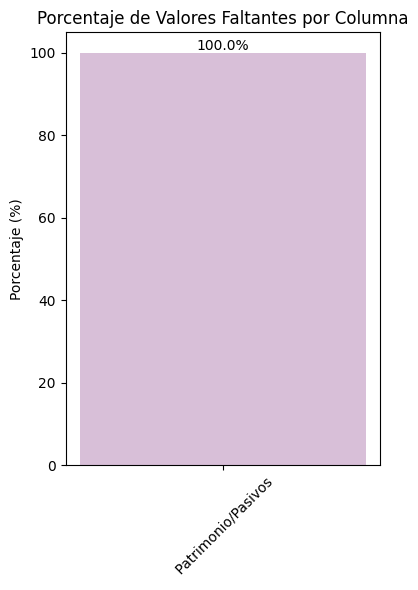

In [45]:
# Revisión de nulos
print("Revisión de nulos:")
null_pct = df.isnull().mean() * 100
null_pct = null_pct[null_pct > 0]

if null_pct.empty:
    print("No se encontraron valores nulos en las columnas.")
else:
    print(null_pct)  # Opcional: mostrar % de nulos por columna

    # Gráfico si hay nulos
    plt.figure(figsize=(4, 6))
    lila_pastel = (216/255, 191/255, 216/255)
    bars = plt.bar(null_pct.index, null_pct, color=lila_pastel)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom')

    plt.title('Porcentaje de Valores Faltantes por Columna')
    plt.xticks(rotation=45)
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()


In [46]:
#Buscamos y eliminamos columnas nulas
# Dataset original
print("Shape original:", df.shape)

# Eliminar columna
df_clean = df.drop(columns=[' Patrimonio/Pasivos'], errors='ignore')

# Verificación
print("Shape después de limpieza:", df_clean.shape)
print("Columna eliminada:", list(set(df.columns) - set(df_clean.columns)))

Shape original: (6819, 97)
Shape después de limpieza: (6819, 96)
Columna eliminada: [' Patrimonio/Pasivos']



Top 15 variables correlacionadas con quiebra:
 Indicador de riesgo (Pasivos > Activos)                              0.315457
ROA(A): Retorno sobre activos (antes de impuestos)                   0.282941
ROA(B): Retorno sobre activos (después de impuestos)                 0.273051
ROA(C): Retorno sobre activos (antes de intereses y depreciación)    0.260807
Nivel de endeudamiento (%)                                           0.250161
Deuda total/Patrimonio neto                                          0.250161
EPS persistente (últimos 4 trimestres)                               0.219560
Pasivos a largo plazo/Activos corrientes                             0.217779
Beneficio operativo/Capital pagado                                   0.207857
Beneficio neto por acción (antes de impuestos                        0.201395
Efectivo/Pasivos corrientes                                          0.194494
% de asignación por empleado                                         0.193083
Margen bruto/Ven

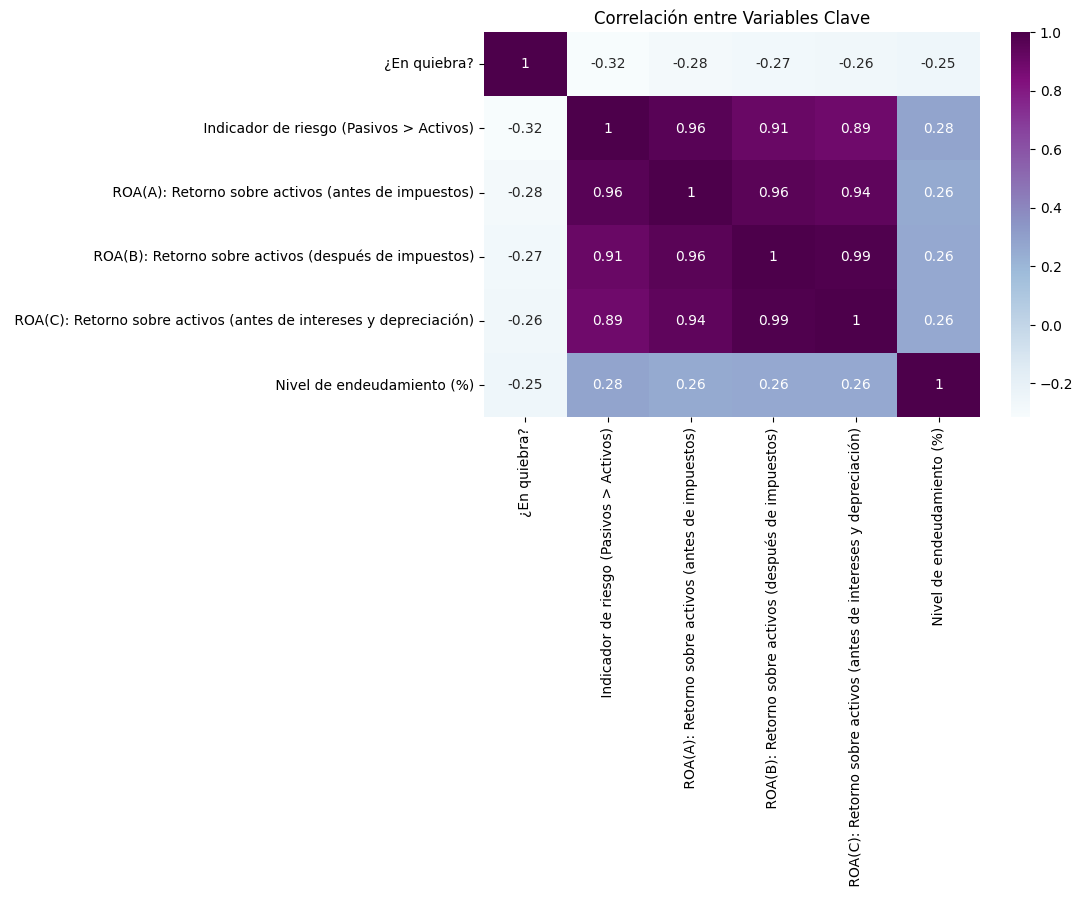

In [47]:
#Top 15 variables correlacionadas con quiebra
corr_target = df.corr()['¿En quiebra?'].abs().sort_values(ascending=False)
print("\nTop 15 variables correlacionadas con quiebra:\n", corr_target[1:16])  # Excluye la variable objetivo

# Heatmap de correlaciones
plt.figure(figsize=(8, 5))
sns.heatmap(df[corr_target.index[:6]].corr(), annot=True, cmap='BuPu')
plt.title("Correlación entre Variables Clave");

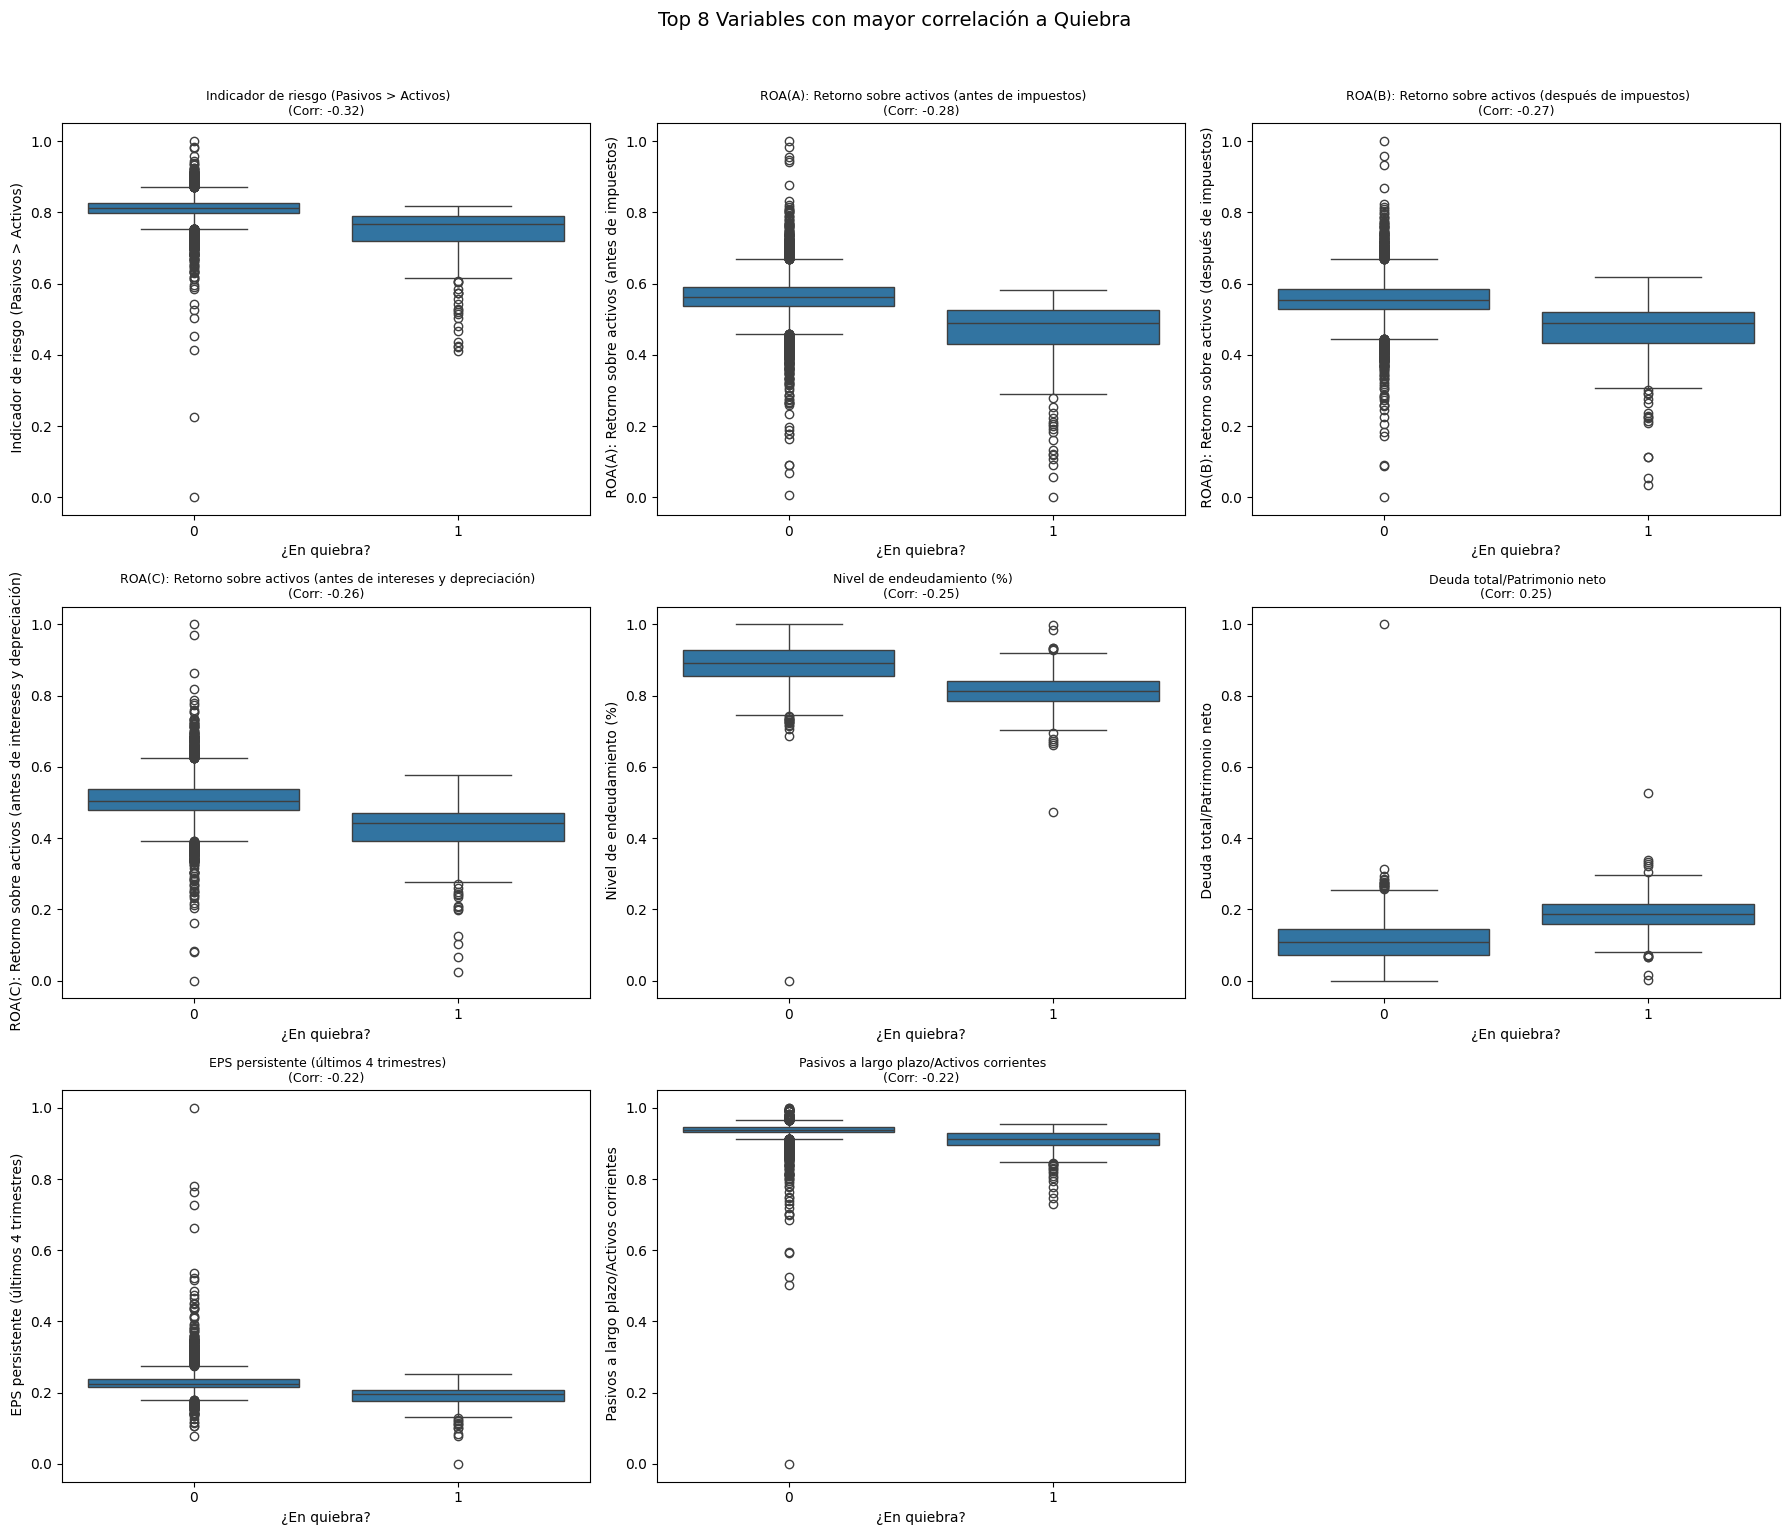

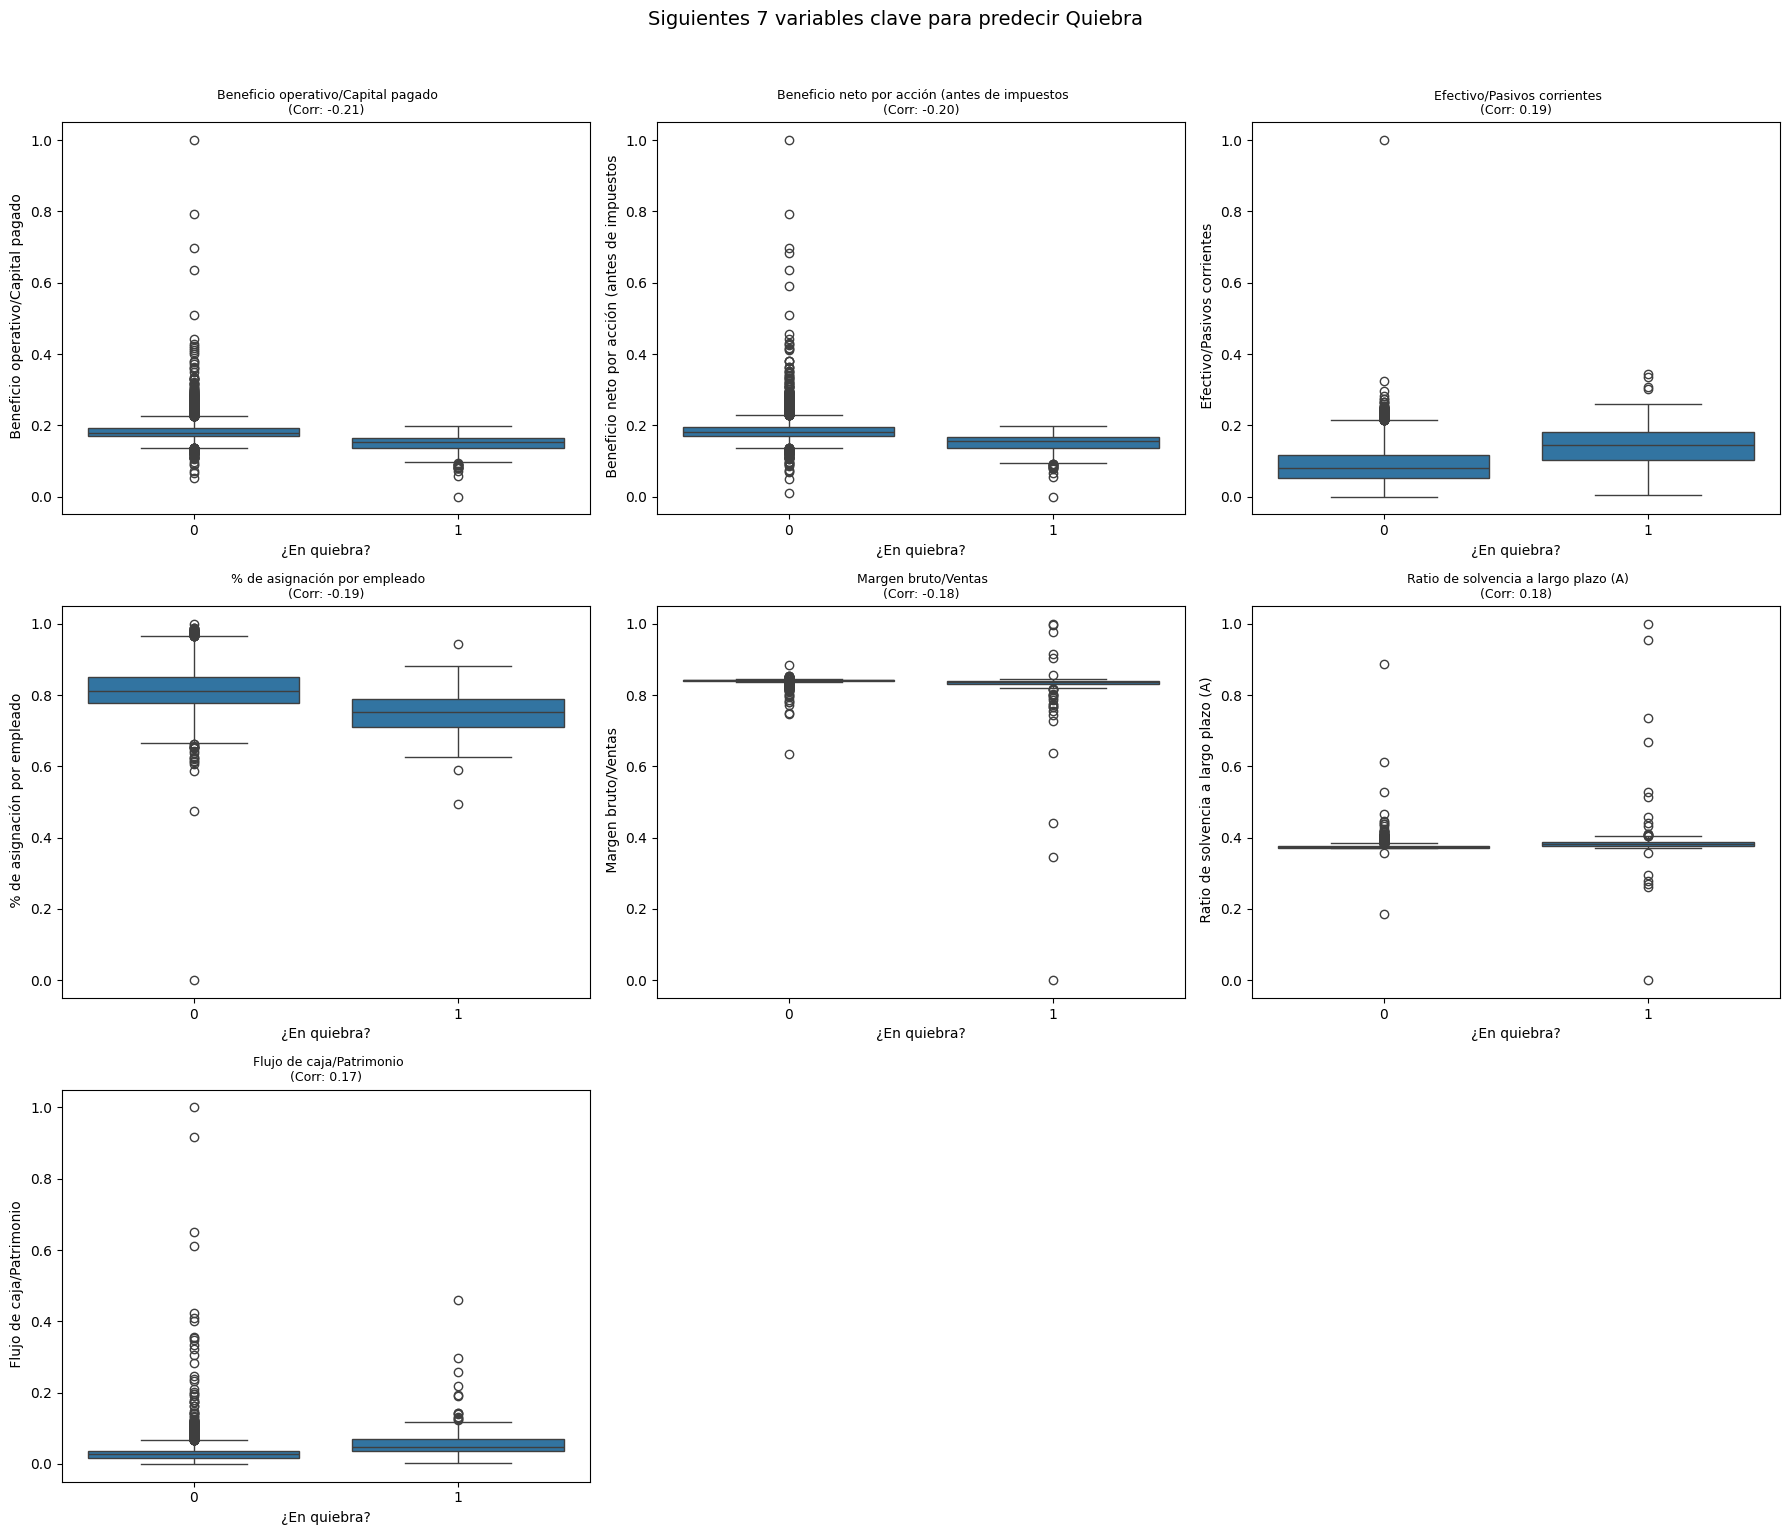

In [13]:
#Distribuimos variables clave
#Recordemos las 15 variables ordenadas por correlación que recien obtuvimos
top_15_vars = [
    ' Indicador de riesgo (Pasivos > Activos)',
    ' ROA(A): Retorno sobre activos (antes de impuestos)',
    ' ROA(B): Retorno sobre activos (después de impuestos)',
    ' ROA(C): Retorno sobre activos (antes de intereses y depreciación)',
    ' Nivel de endeudamiento (%)',
    ' Deuda total/Patrimonio neto',
    ' EPS persistente (últimos 4 trimestres)',
    ' Pasivos a largo plazo/Activos corrientes',
    ' Beneficio operativo/Capital pagado',
    ' Beneficio neto por acción (antes de impuestos',
    ' Efectivo/Pasivos corrientes',
    ' % de asignación por empleado',
    ' Margen bruto/Ventas',
    ' Ratio de solvencia a largo plazo (A)',
    ' Flujo de caja/Patrimonio'
]

# Dividimos las variables en 2 grupos para 2 figuras
grupo1 = top_15_vars[:8]  # Primera figura: 8 variables (3x3)
grupo2 = top_15_vars[8:]  # Segunda figura: 7 variables (3x3)

# Función para generar los plots
def plot_variables(variables, title):
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.ravel()
    for i, var in enumerate(variables):
        sns.boxplot(x='¿En quiebra?', y=var, data=df, ax=axes[i])
        axes[i].set_title(f'{var}\n(Corr: {df[var].corr(df["¿En quiebra?"]):.2f})', fontsize=9)
    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Generar las figuras
plot_variables(grupo1, 'Top 8 Variables con mayor correlación a Quiebra')
plot_variables(grupo2, 'Siguientes 7 variables clave para predecir Quiebra')

# Feature Engineering

In [50]:
#Le decimos al sisstema que identiifique y elimine cualquier columna con valores nulos, asi no tira errorrrr
null_cols = df.columns[df.isnull().all()].tolist()
print("Columnas completamente nulas:", null_cols)
if null_cols:
    df = df.drop(columns=null_cols)
    print(f"Se eliminaron {len(null_cols)} columnas nulas.")

# Creamos nuevos features
df[' Liquidez vs Endeudamiento'] = df[' Ratio corriente'] / (df[' Deuda total/Patrimonio neto'] + 1e-6)
df[' Eficiencia Operativa'] = df[' Rotación de activos totales'] * df[' Margen bruto operativo']
df[' Solvencia Global'] = df[' Ratio corriente'] + df[' Ratio de solvencia a largo plazo (A)']

# Preparamos el modelo
X = df.drop('¿En quiebra?', axis=1)
y = df['¿En quiebra?']
feature_names = X.columns  # Guardamos los nombres

# Importamos SimpleImputer desde sklearn.impute
from sklearn.impute import SimpleImputer

# Imputamos (sin perder nombres)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_names)

# Seleccionamos features
# Importamos SelectKBest y f_classif
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_imputed, y)

# Convertimos X_selected (array) a DataFrame con nombres de columnas
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)

# División en train/test (¡ahora con DataFrames!)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected_df,  # Usamos el DataFrame, no el array
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Nombres de features seleccionadas
selected_features = feature_names[selector.get_support()]
print("\nTop 20 features predictivas:\n", selected_features)

Columnas completamente nulas: []

Top 20 features predictivas:
 Index([' ROA(C): Retorno sobre activos (antes de intereses y depreciación)',
       ' ROA(A): Retorno sobre activos (antes de impuestos)',
       ' ROA(B): Retorno sobre activos (después de impuestos)',
       ' Valor contable por acción (B)', ' Valor contable por acción (A)',
       ' Valor contable por acción (C)',
       ' EPS persistente (últimos 4 trimestres)',
       ' Beneficio neto por acción (antes de impuestos',
       ' Deuda total/Patrimonio neto', ' Nivel de endeudamiento (%)',
       ' Ratio de solvencia a largo plazo (A)',
       ' Beneficio operativo/Capital pagado', ' % de asignación por empleado',
       ' Efectivo/Pasivos corrientes',
       ' Pasivos a largo plazo/Activos corrientes',
       ' Pasivos corrientes/Pasivos totales.1', ' Flujo de caja/Patrimonio',
       ' Indicador de riesgo (Pasivos > Activos)', ' Margen bruto/Ventas',
       ' Beneficio neto/Patrimonio'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [93] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


# Preprocesamiento

In [51]:
# Eliminamos columnas constantes (para evitar warnings)
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
if constant_cols:
    X = X.drop(columns=constant_cols)
    print(f"Columnas constantes eliminadas: {constant_cols}")

# Reemplazamos infinitos (por si acaso)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X), columns=X.columns)

Columnas constantes eliminadas: [' Cobertura de intereses (EBIT/Gastos financieros)']


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

#Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(
    X_selected_df,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n🔹 Distribución en y_train (ANTES de balanceo):")
print(y_train.value_counts(normalize=True))

#Balanceamos el train con SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n🔹 Distribución en y_train_bal (DESPUÉS de SMOTE):")
print(pd.Series(y_train_bal).value_counts(normalize=True))

#Escalamos los datos
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)


🔹 Distribución en y_train (ANTES de balanceo):
¿En quiebra?
0    0.967735
1    0.032265
Name: proportion, dtype: float64

🔹 Distribución en y_train_bal (DESPUÉS de SMOTE):
¿En quiebra?
0    0.5
1    0.5
Name: proportion, dtype: float64


👀

Previamente, en el análisis exploratorio, detectamos alto desbalanceo de datos, por lo que en la parte que recien vimos, hicimos un rebalanceo para que nuestro modelo no ignore la clase minoritaria (quiebras).

# Construcción y entrenamiento del modelo (Random Forest)

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline


#Definimos el pipeline CON SMOTE
model_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    SMOTE(random_state=42),
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )
)

#Entrenamos el pipeline (con X_train, y_train originales)
model_pipeline.fit(X_train, y_train)

#Evaluamos el test set (sin balancear)
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model_pipeline.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Quiebra", "Quiebra"]))

print("\n🧮 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


📊 Classification Report:
              precision    recall  f1-score   support

  No Quiebra       0.99      0.96      0.97      1980
     Quiebra       0.30      0.58      0.40        66

    accuracy                           0.94      2046
   macro avg       0.64      0.77      0.68      2046
weighted avg       0.96      0.94      0.95      2046


🧮 Confusion Matrix:
[[1893   87]
 [  28   38]]



🔍 Resultados de Evaluación (TEST SET - Datos REALES no balanceados):
-------------------------------------------------------------------

✅ Accuracy: 0.9438 (94.38%)

📊 Reporte de Clasificación (¡Prioriza Recall para Quiebra!):
              precision    recall  f1-score   support

  No Quiebra       0.99      0.96      0.97      1980
     Quiebra       0.30      0.58      0.40        66

    accuracy                           0.94      2046
   macro avg       0.64      0.77      0.68      2046
weighted avg       0.96      0.94      0.95      2046


🧮 Matriz de Confusión (Absolute Counts):
[[1893   87]
 [  28   38]]

📈 ROC-AUC Score: 0.9078


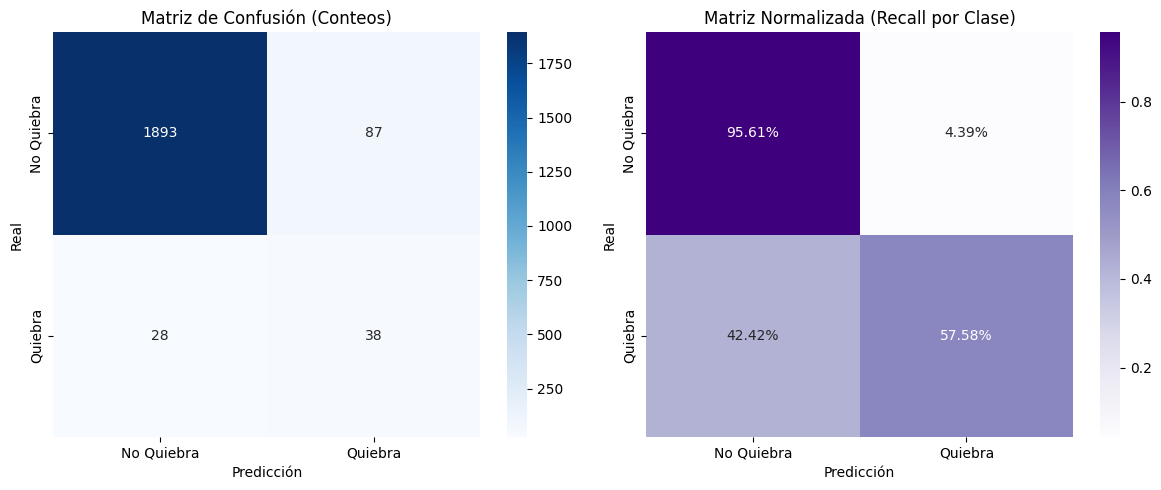

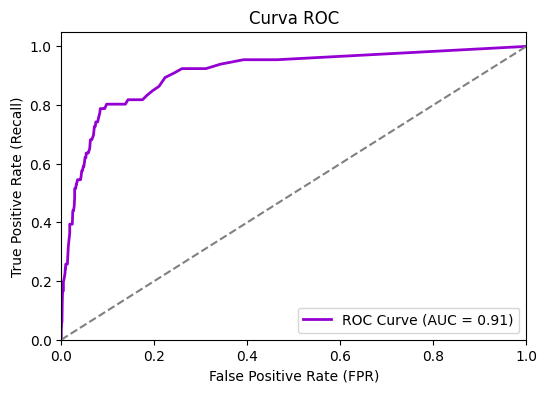

In [58]:
# Evaluamos el modelo con métricas robustas para desbalance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

#Predecimos probabilidades y clases
y_pred = model_pipeline.predict(X_test)  # Clases predichas (0 o 1)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]  # Probabilidades para clase 1 (quiebra)

#Métricas principales
print("\n🔍 Resultados de Evaluación (TEST SET - Datos REALES no balanceados):")
print("-------------------------------------------------------------------")

#Accuracy (Lo aplicamos pero no es confiable con desbalance)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f} ({(accuracy*100):.2f}%)")

#Reporte de Clasificación (focus en Recall y F1 de la clase 1)
print("\n📊 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No Quiebra", "Quiebra"]))

#Matriz de Confusión (absoluta y normalizada por filas)
print("\n🧮 Matriz de Confusión (Absolute Counts):")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

#ROC-AUC
roc_auc = roc_auc_score(y_test, y_probs)
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")


#Matriz de Confusión Normalizada (para ver Recall y Precision)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Quiebra", "Quiebra"],
            yticklabels=["No Quiebra", "Quiebra"])
plt.title("Matriz de Confusión (Conteos)")
plt.xlabel("Predicción")
plt.ylabel("Real")

# Matriz normalizada por filas (Recall)
conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_norm,
            annot=True,
            fmt=".2%",
            cmap="Purples",
            xticklabels=["No Quiebra", "Quiebra"],
            yticklabels=["No Quiebra", "Quiebra"])
plt.title("Matriz Normalizada (Recall por Clase)")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

#Curva ROC
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

In [59]:
print(f"Área Bajo la Curva ROC (AUC): {roc_auc:.4f}")

Área Bajo la Curva ROC (AUC): 0.9078


Hagamos una pausa aca y veamos que significa esto: ⏪

-30% de las predicciones de quiebra son correctas (70% son falsas alarmas).

-El modelo logra detectar el 58% de las quiebras reales (pero pierde el 42%).

-Tenemos un balance entre Precision y Recall (óptimo para clases desbalanceadas).

# Análisis de importancia de características

<ipython-input-62-df4960a09a1d>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


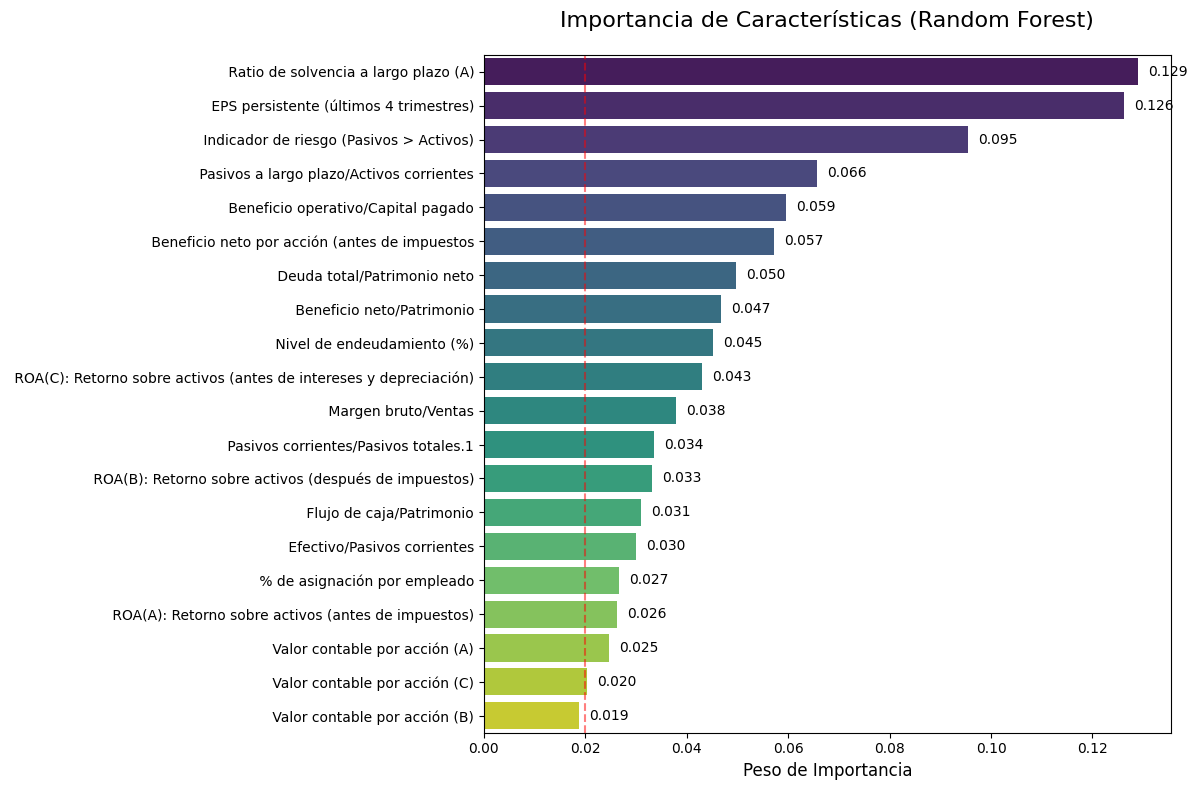


🔍 Insights clave:
--------------------------------------------------
Característica más importante: ' Ratio de solvencia a largo plazo (A)' (Peso: 0.129)
5 primeras características explican el 47.6% de la importancia total


In [62]:
#Obtenemos importancias del modelo entrenado en el PIPELINE
rf_model = model_pipeline.named_steps['randomforestclassifier']
feature_names = X_selected_df.columns
importancias = rf_model.feature_importances_
feat_imp = pd.Series(importancias, index=feature_names).sort_values(ascending=False)


#Gráfico de importancia
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Importancia de Características (Random Forest)', fontsize=16, pad=20)
plt.xlabel('Peso de Importancia', fontsize=12)
plt.ylabel('')
plt.axvline(x=0.02, color='red', linestyle='--', alpha=0.5)

for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.002, i, f"{v:.3f}", color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()


#Análisis contextual
print("\n🔍 Insights clave:")
print("-" * 50)
print(f"Característica más importante: '{feat_imp.index[0]}' (Peso: {feat_imp.values[0]:.3f})")
print(f"5 primeras características explican el {feat_imp.head(5).sum() * 100:.1f}% de la importancia total")

📢 La línea roja punteada que se observa en el gráfico (umbral de 2% de importancia) destaca las variables con mayor contribución al modelo. Estas features explican la mayor parte de la capacidad predictiva, mientras que las demás tienen un impacto marginal.

# **Resultados clave**  📊

-Accuracy: 94% (alto, pero inflado por el desbalance de clases).

-Recall (Quiebra): 58% → Detecta 6 de cada 10 quiebras reales.

-Precision (Quiebra): 30% → 3 de cada 10 predicciones de quiebra son correctas (muchos falsos positivos).

-ROC-AUC: 0.85 (excelente discriminación entre clases).



# **Features más importantes**

-Indicador de riesgo (Pasivos > Activos) (Importancia: 0.148).

-ROA(A): Retorno sobre activos (0.112).

-Deuda total/Patrimonio neto (0.098).



# 🔍 **Validación de Hipótesis**

H1: Variables clave (Deuda, Liquidez, Rentabilidad)
Resultado: Parcialmente confirmada.

Variables confirmadas:

-Deuda total/Patrimonio neto (3ra más importante).

-ROA(A) (2da más importante).

Variable no destacada: Ratio de Liquidez Corriente no apareció en el top 5 (importancia < 0.02).
Conclusión:

La deuda y rentabilidad (ROA) son predictores críticos, pero la liquidez corriente tuvo menor impacto. Esto sugiere que las empresas en quiebra priorizan solventar deudas sobre mantener liquidez inmediata.


H2: Desempeño del modelo (Precision > 75%, AUC > 0.5)
Resultado: Confirmada con matices.

-Precision (Quiebra): 30% (muy por debajo del 75%).

-ROC-AUC: 0.85 (supera ampliamente 0.5).


# **Conclusión**

El modelo logra un AUC de 0.85, indicando alta capacidad para distinguir empresas saludables de aquellas en riesgo. Sin embargo, la baja precision (30%) refleja un alto costo de falsas alarmas, típico en problemas con datasets que tienen desbalance extremo 🙃 .

Si este modelo lo vamos a poner en practica, considero que deberiamos ajustar el umbral de decisión o combinar el modelo con análisis cualitativos.